Loading HCC Dataset...
HEPATOCELLULAR CARCINOMA RECURRENCE PREDICTION SYSTEM
Dataset Shape: (204, 50)
Number of Patients: 204
Number of Features: 50

DATASET OVERVIEW

 Column Categories Analysis:
• Demographic Features: 2
• Clinical Features: 4
• Liver Function Tests: 9
• Tumor Markers: 1
• Blood Parameters: 5
• Comorbidities: 14
• Tumor Characteristics: 2
• Complications: 5

 TARGET VARIABLE ANALYSIS


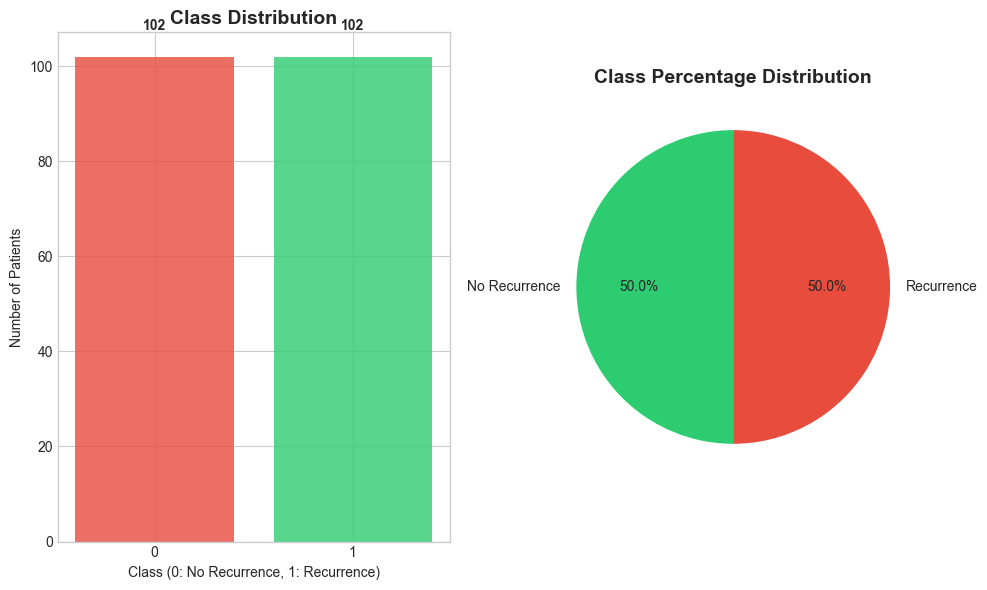

Recurrence Rate: 50.00%
Non-Recurrence Rate: 50.00%

 DATA QUALITY ASSESSMENT
Features with missing values: 0
No missing values found in the dataset!

 DATA TYPES INFORMATION
Data Types Distribution:
• int64: 34 features
• float64: 16 features

Categorical Features: 0
Numerical Features: 49

 STATISTICAL SUMMARY - NUMERICAL FEATURES
            count        mean         std    min      25%        50%  \
Age         204.0      65.529      12.778  20.00   58.750     67.000   
AFP         204.0   15882.190  131117.483   1.20    6.050     62.450   
Total_Bil   204.0       3.165       5.854   0.30    0.900      1.400   
Albumin     204.0       3.417       0.649   1.90    3.000      3.400   
ALT         204.0      66.373      52.971  11.00   31.000     53.000   
AST         204.0      96.025      81.639  17.00   48.000     73.500   
Platelets   204.0  116677.461  107643.411   1.71  256.558  96370.030   
INR         204.0       1.444       0.483   0.84    1.180      1.320   
Creatinine  204.0

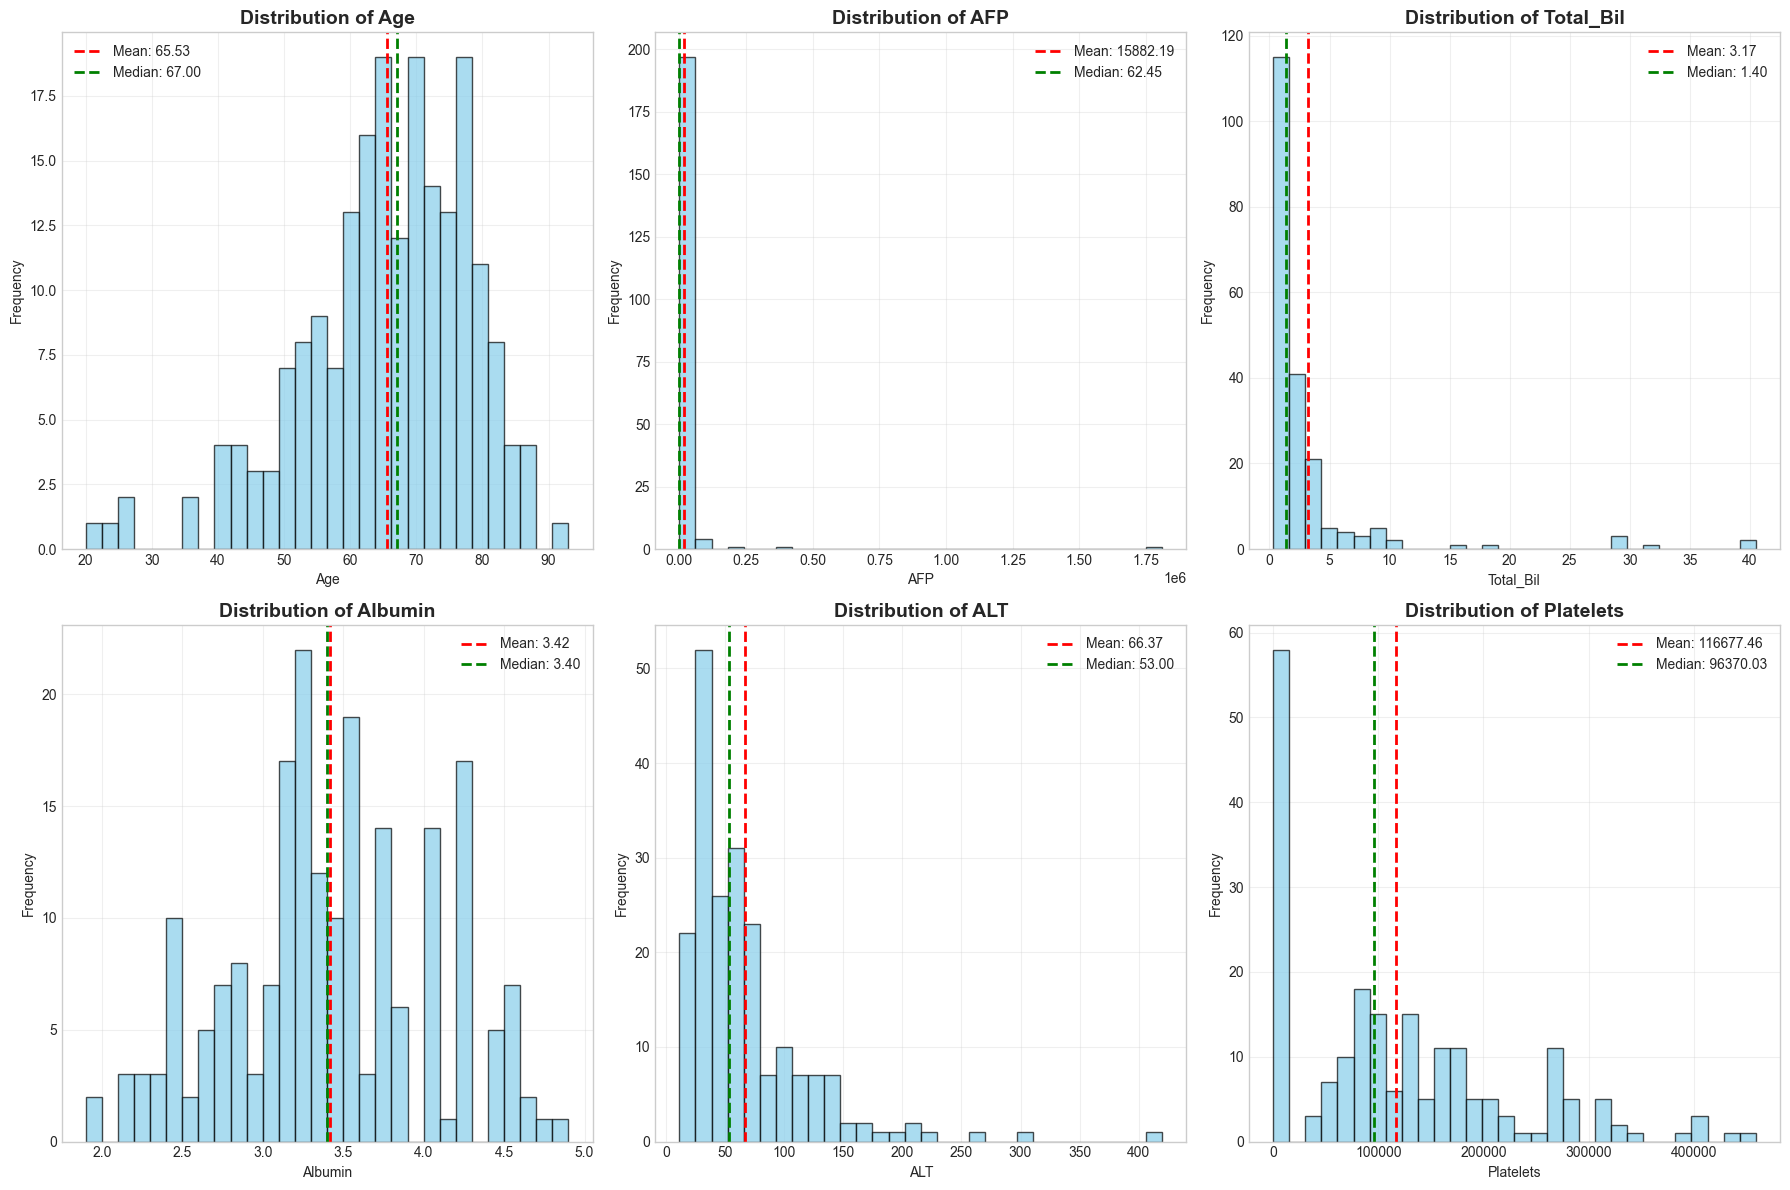


 CORRELATION ANALYSIS


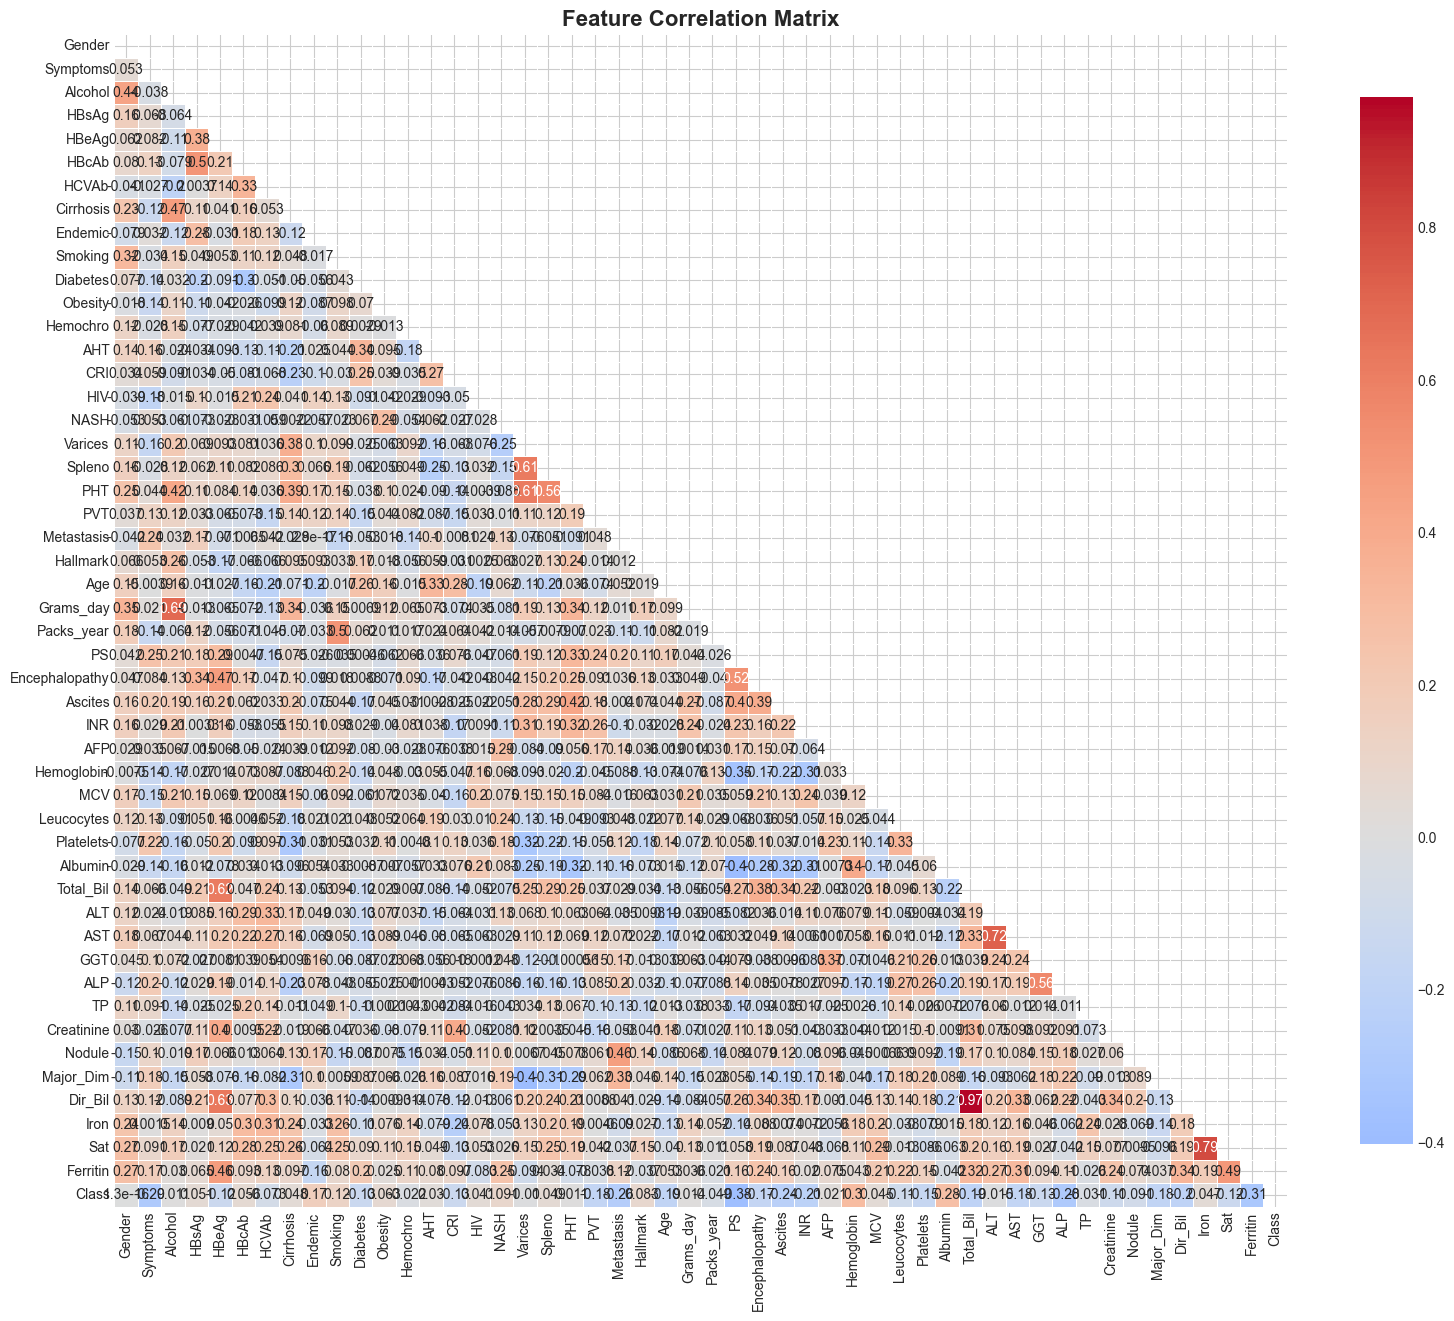


Top 10 Features Correlated with Recurrence:
Class         1.000000
Hemoglobin    0.298990
Albumin       0.276002
Endemic       0.166667
Smoking       0.118217
NASH          0.090815
Hallmark      0.082602
Obesity       0.063214
HBcAb         0.055891
HBsAg         0.050601
Name: Class, dtype: float64

Bottom 10 Features Correlated with Recurrence:
Age          -0.185358
Total_Bil    -0.193383
Dir_Bil      -0.199224
INR          -0.214570
Ascites      -0.235074
Metastasis   -0.260374
ALP          -0.284098
Symptoms     -0.286473
Ferritin     -0.313703
PS           -0.381087
Name: Class, dtype: float64

 SAVING PROCESSED DATASET
 Data analysis completed successfully!
 Reports saved in '../reports/' directory
 Processed data structure prepared for next phase

PHASE 1 COMPLETED: DATA ANALYSIS & PREPROCESSING
 Key Findings:
• Dataset contains 204 patients with 50 features
• Recurrence rate: 50.00%
• Missing values found in 0 features
• Strongest correlation with recurrence: Hemoglobin (0.2

In [ ]:
# %% [markdown]
"""
# HCC Recurrence Prediction - Data Analysis & Preprocessing
## Complete Implementation for Final Year Project
"""

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for professional plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# %%
# Load the dataset
print("Loading HCC Dataset...")
df = pd.read_excel('../data/raw/hcc-data-complete-balanced.xlsx')

print("=" * 80)
print("HEPATOCELLULAR CARCINOMA RECURRENCE PREDICTION SYSTEM")
print("=" * 80)
print(f"Dataset Shape: {df.shape}")
print(f"Number of Patients: {len(df)}")
print(f"Number of Features: {len(df.columns)}")

# %%
# Comprehensive dataset overview
print("\n" + "=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print("\n Column Categories Analysis:")
# Categorize features based on medical domain knowledge
demographic_features = ['Gender', 'Age']
clinical_features = ['Symptoms', 'PS', 'Encephalopathy', 'Ascites']
liver_function_features = ['INR', 'Albumin', 'Total_Bil', 'Dir_Bil', 'ALT', 'AST', 'GGT', 'ALP', 'TP']
tumor_markers = ['AFP']
blood_parameters = ['Hemoglobin', 'MCV', 'Leucocytes', 'Platelets', 'Creatinine']
comorbidity_features = ['Alcohol', 'HBsAg', 'HBeAg', 'HBcAb', 'HCVAb', 'Cirrhosis', 'Diabetes', 
                       'Obesity', 'Hemochro', 'AHT', 'CRI', 'HIV', 'NASH', 'Smoking']
tumor_characteristics = ['Nodules', 'Major_Dim']
complications = ['Varices', 'Splenomegaly', 'PHT', 'PVT', 'Metastasis']

print(f"• Demographic Features: {len(demographic_features)}")
print(f"• Clinical Features: {len(clinical_features)}")
print(f"• Liver Function Tests: {len(liver_function_features)}")
print(f"• Tumor Markers: {len(tumor_markers)}")
print(f"• Blood Parameters: {len(blood_parameters)}")
print(f"• Comorbidities: {len(comorbidity_features)}")
print(f"• Tumor Characteristics: {len(tumor_characteristics)}")
print(f"• Complications: {len(complications)}")

# %%
# Target variable analysis
print("\n TARGET VARIABLE ANALYSIS")
print("=" * 40)

class_distribution = df['Class'].value_counts()
class_percentage = df['Class'].value_counts(normalize=True) * 100

plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#e74c3c']
plt.subplot(1, 2, 1)
bars = plt.bar(class_distribution.index, class_distribution.values, color=colors, alpha=0.8)
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Class (0: No Recurrence, 1: Recurrence)')
plt.ylabel('Number of Patients')
plt.xticks([0, 1])

# Add value labels on bars
for bar, value in zip(bars, class_distribution.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{value}', ha='center', va='bottom', fontweight='bold')

plt.subplot(1, 2, 2)
plt.pie(class_distribution.values, labels=['No Recurrence', 'Recurrence'], 
        colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Class Percentage Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Recurrence Rate: {class_percentage[1]:.2f}%")
print(f"Non-Recurrence Rate: {class_percentage[0]:.2f}%")

# %%
# Data Quality Assessment
print("\n DATA QUALITY ASSESSMENT")
print("=" * 40)

# Missing values analysis
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percentage
}).sort_values('Missing Percentage', ascending=False)

# Display features with missing values
missing_features = missing_info[missing_info['Missing Count'] > 0]
print(f"Features with missing values: {len(missing_features)}")

if len(missing_features) > 0:
    print("\nMissing Value Analysis:")
    print(missing_features.head(10))
else:
    print("No missing values found in the dataset!")

# %%
# Data types information
print("\n DATA TYPES INFORMATION")
print("=" * 40)

data_types = df.dtypes.value_counts()
print("Data Types Distribution:")
for dtype, count in data_types.items():
    print(f"• {dtype}: {count} features")

# Identify categorical and numerical features
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove target variable from numerical features
if 'Class' in numerical_features:
    numerical_features.remove('Class')

print(f"\nCategorical Features: {len(categorical_features)}")
print(f"Numerical Features: {len(numerical_features)}")

# %%
# Statistical Summary for Numerical Features
print("\n STATISTICAL SUMMARY - NUMERICAL FEATURES")
print("=" * 50)

# Select top 10 most important numerical features for initial analysis
important_numerical = ['Age', 'AFP', 'Total_Bil', 'Albumin', 'ALT', 'AST', 'Platelets', 
                      'INR', 'Creatinine', 'Major_Dim']

stat_summary = df[important_numerical].describe().T
stat_summary['variance'] = df[important_numerical].var()
stat_summary['skewness'] = df[important_numerical].skew()
stat_summary['kurtosis'] = df[important_numerical].kurtosis()

print(stat_summary.round(3))

# %%
# Distribution plots for key numerical features
print("\n DISTRIBUTION OF KEY CLINICAL FEATURES")
print("=" * 50)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
key_features = ['Age', 'AFP', 'Total_Bil', 'Albumin', 'ALT', 'Platelets']

for idx, feature in enumerate(key_features):
    row, col = idx // 3, idx % 3
    ax = axes[row, col]
    
    # Plot distribution
    n, bins, patches = ax.hist(df[feature], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    
    # Add vertical line for mean
    ax.axvline(df[feature].mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {df[feature].mean():.2f}')
    
    # Add vertical line for median
    ax.axvline(df[feature].median(), color='green', linestyle='--', linewidth=2, 
               label=f'Median: {df[feature].median():.2f}')
    
    ax.set_title(f'Distribution of {feature}', fontsize=14, fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %%
# Correlation Analysis
print("\n CORRELATION ANALYSIS")
print("=" * 40)

# Calculate correlation matrix for numerical features
correlation_matrix = df[numerical_features + ['Class']].corr()

# Plot correlation heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with target variable
target_correlations = correlation_matrix['Class'].sort_values(ascending=False)
print("\nTop 10 Features Correlated with Recurrence:")
print(target_correlations.head(10))

print("\nBottom 10 Features Correlated with Recurrence:")
print(target_correlations.tail(10))

# %%
# Save processed dataset
print("\n SAVING PROCESSED DATASET")
print("=" * 40)

# Create data quality report
data_quality_report = {
    'dataset_shape': df.shape,
    'class_distribution': class_distribution.to_dict(),
    'missing_values_summary': missing_info.to_dict(),
    'feature_categories': {
        'demographic': len(demographic_features),
        'clinical': len(clinical_features),
        'liver_function': len(liver_function_features),
        'tumor_markers': len(tumor_markers),
        'blood_parameters': len(blood_parameters),
        'comorbidities': len(comorbidity_features),
        'tumor_characteristics': len(tumor_characteristics),
        'complications': len(complications)
    },
    'target_correlations': target_correlations.to_dict()
}

import json
import os

# Create directories if they don't exist
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

# Save data quality report
with open('../reports/data_quality_report.json', 'w') as f:
    json.dump(data_quality_report, f, indent=4)

print(" Data analysis completed successfully!")
print(" Reports saved in '../reports/' directory")
print(" Processed data structure prepared for next phase")

# %%
print("\n" + "=" * 80)
print("PHASE 1 COMPLETED: DATA ANALYSIS & PREPROCESSING")
print("=" * 80)
print(" Key Findings:")
print(f"• Dataset contains {df.shape[0]} patients with {df.shape[1]} features")
print(f"• Recurrence rate: {class_percentage[1]:.2f}%")
print(f"• Missing values found in {len(missing_features)} features")
print(f"• Strongest correlation with recurrence: {target_correlations.index[1]} ({target_correlations[1]:.3f})")
print(" Next: Feature Engineering and Model Preparation")

In [6]:
print("Code ran successfully!")


Code ran successfully!
